Визуализация бенмарков

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [ ]:
df_random = pd.read_csv("benchmark_results.csv")

df_random.describe()

df_random_clean = df_random[df_random['exact_cost'] > 0].copy()
df_random_clean['ratio'] = df_random_clean['approx_cost'] / df_random_clean['exact_cost']

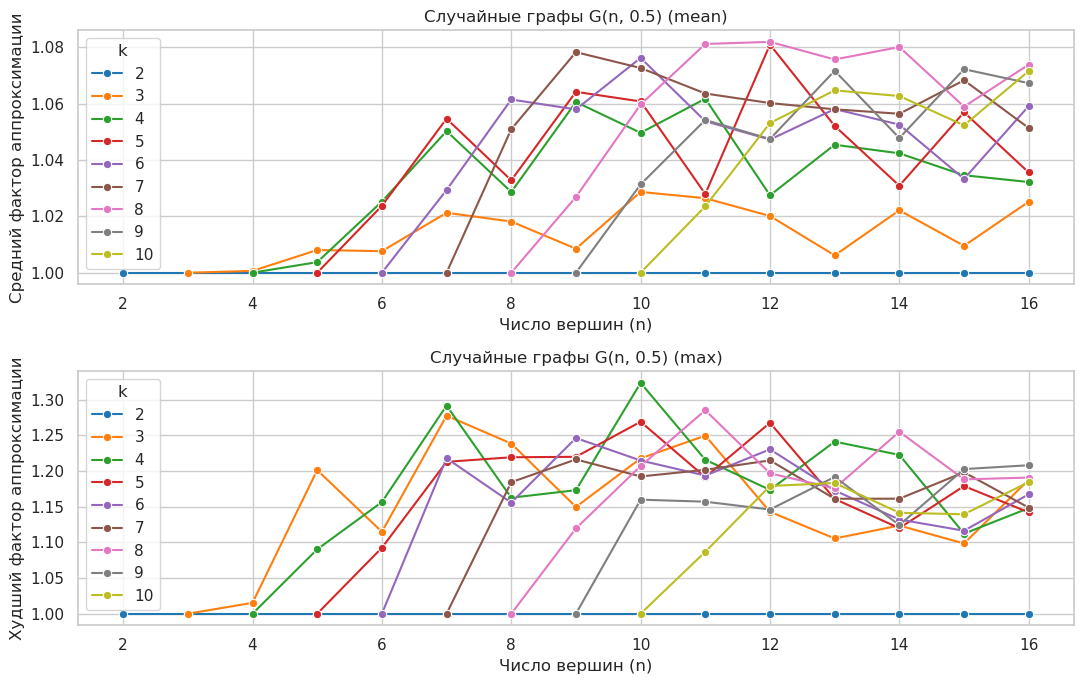

In [ ]:
grouped_mean = df_random_clean.groupby(['graph_type', 'n', 'k'])['ratio'].mean().reset_index()
grouped_max = df_random_clean.groupby(['graph_type', 'n', 'k'])['ratio'].max().reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

df_rand_mean = grouped_mean[grouped_mean['graph_type'] == 'random']
df_rand_max = grouped_max[grouped_max['graph_type'] == 'random']

sns.lineplot(data=df_rand_mean, x='n', y='ratio', hue='k', marker='o', ax=ax1, palette='tab10')
ax1.set_title('Случайные графы $G(n, 0.5)$ (mean)')
ax1.set_xlabel('Число вершин (n)')
ax1.set_ylabel('Средний фактор аппроксимации')

sns.lineplot(data=df_rand_max, x='n', y='ratio', hue='k', marker='o', ax=ax2, palette='tab10')
ax2.set_title('Случайные графы $G(n, 0.5)$ (max)')
ax2.set_xlabel('Число вершин (n)')
ax2.set_ylabel('Худший фактор аппроксимации')

plt.tight_layout()
plt.show()

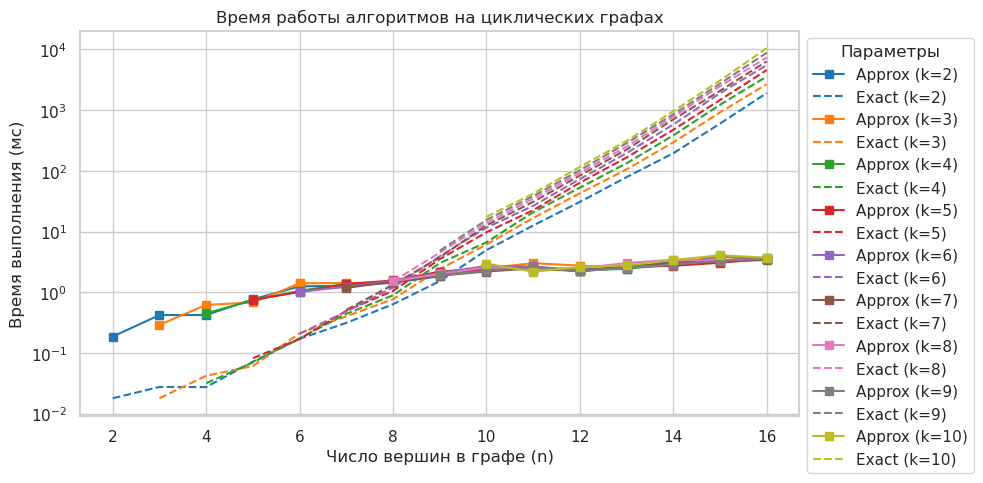

In [ ]:
time_df = df_random.groupby(['graph_type', 'n', 'k'])[['approx_time_ms', 'exact_time_ms']].mean().reset_index()
time_df_random = time_df[time_df['graph_type'] == 'random']

plt.figure(figsize=(10, 5))

unique_k = sorted(time_df_random['k'].unique())
colors = sns.color_palette("tab10", len(unique_k))

for i, k in enumerate(unique_k):
    sub = time_df_random[time_df_random['k'] == k]
    
    plt.plot(sub['n'], sub['approx_time_ms'], marker='s', color=colors[i], label=f'Approx (k={k})')
    plt.plot(sub['n'], sub['exact_time_ms'], linestyle='--', color=colors[i], label=f'Exact (k={k})')

plt.yscale('log')
plt.title('Время работы алгоритмов на графах $G(n, 0.5)$')
plt.xlabel('Число вершин в графе (n)')
plt.ylabel('Время выполнения (мс)')
plt.legend(title="Параметры", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [76]:
df_cycle = pd.read_csv("benchmark_cycle_results.csv")

df_cycle.describe()

df_cycle_clean = df_cycle[df_cycle['exact_cost'] > 0].copy()
df_cycle_clean['ratio'] = df_cycle_clean['approx_cost'] / df_cycle_clean['exact_cost']

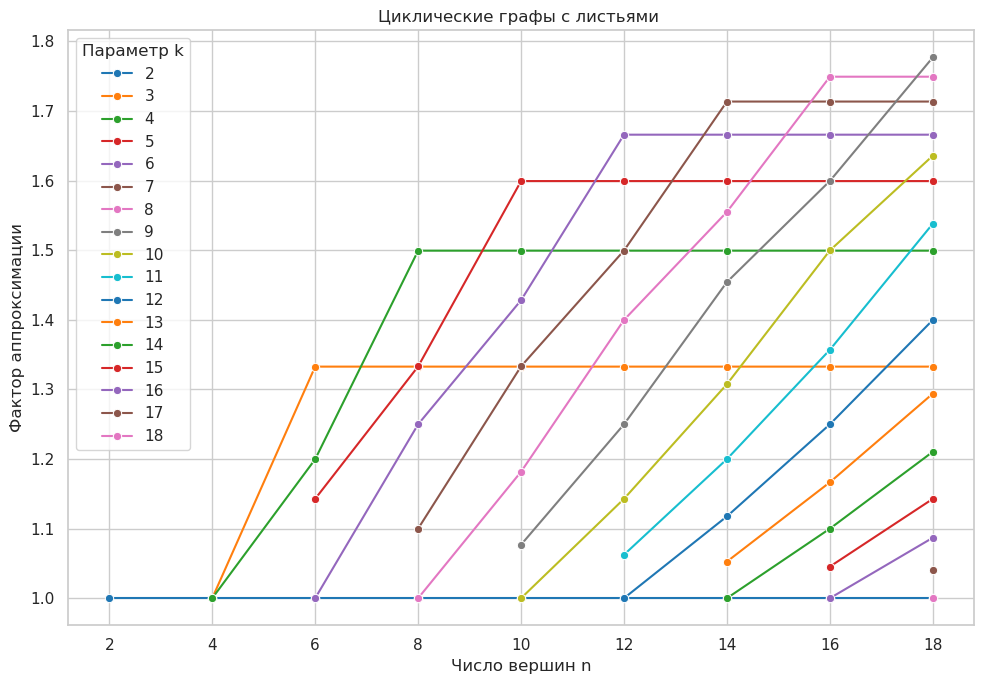

In [80]:
data = df_cycle_clean.groupby(['graph_type', 'n', 'k'])['ratio'].mean().reset_index()

plt.figure(figsize=(10, 7))

sns.lineplot(
    data=data, 
    x='n', 
    y='ratio', 
    hue='k', 
    marker='o', 
    palette='tab10'
)

plt.title('Циклические графы с листьями ')
plt.xlabel('Число вершин n')
plt.ylabel('Фактор аппроксимации')
plt.legend(title='Параметр k')

plt.tight_layout()
plt.show()

Большие значения $n$

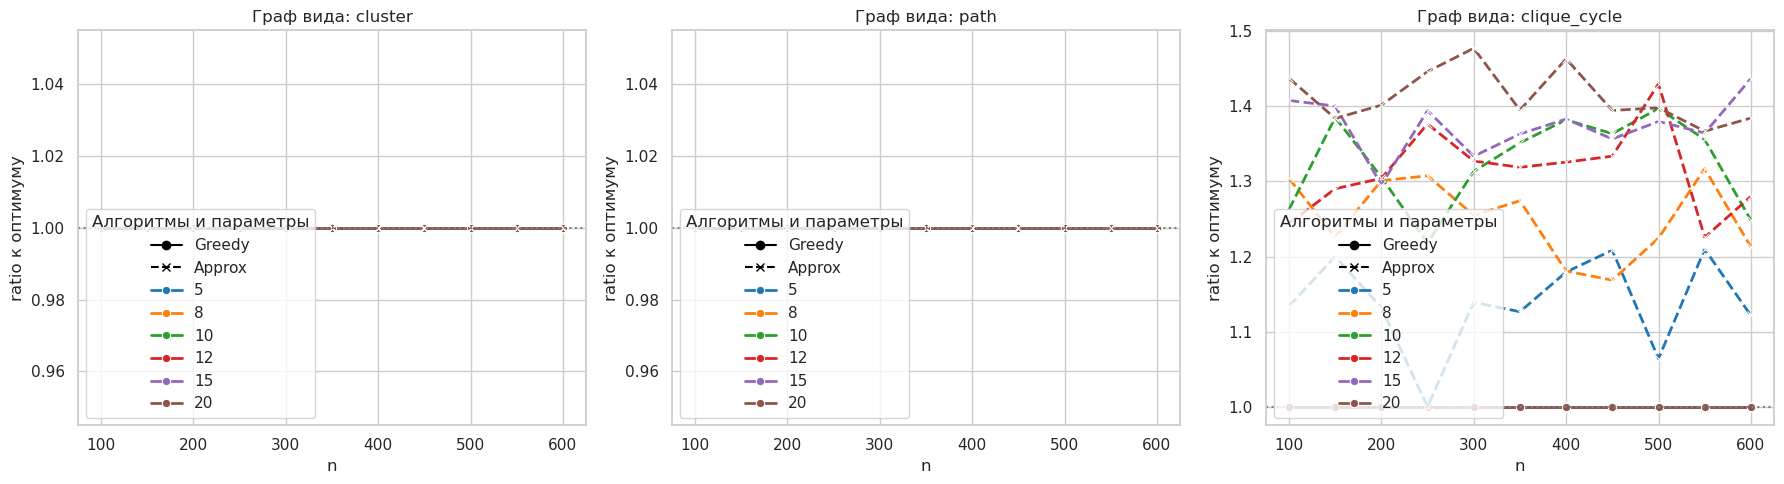

In [ ]:
df = pd.read_csv("benchmark_greedy_results.csv")

df = df[df['bound_cost'] > 0]
df = df[df['k'] > 3]

df['greedy_ratio'] = df['greedy_cost'] / df['bound_cost']
df['approx_ratio'] = df['approx_cost'] / df['bound_cost']

df = df[df['graph_type'].isin(['cluster', 'path', 'clique_cycle'])]

grouped = df.groupby(['graph_type', 'n', 'k']).mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
types = ['cluster', 'path', 'clique_cycle']

for i, t in enumerate(types):
    cur = grouped[grouped['graph_type'] == t]
    ax = axes[i]

    sns.lineplot(
        data=cur, x='n', y='greedy_ratio', hue='k', 
        marker='o', linestyle='-', linewidth=2,
        ax=ax, palette='tab10'
    )

    sns.lineplot(
        data=cur, x='n', y='approx_ratio', hue='k', 
        marker='x', linestyle='--', linewidth=2,
        ax=ax, palette='tab10'
    )

    ax.set_title('Граф вида: ' + t)
    ax.set_xlabel('n')
    ax.set_ylabel('ratio к оптимуму')
    ax.axhline(1.0, color='gray', linestyle=':')

    handles, labels = ax.get_legend_handles_labels()
    
    from matplotlib.lines import Line2D
    custom_handles = [
        Line2D([0], [0], color='black', linestyle='-', marker='o', label='Greedy'),
        Line2D([0], [0], color='black', linestyle='--', marker='x', label='Approx'),
    ]
    
    half_length = len(handles) // 2
    ax.legend(handles=custom_handles +handles[:half_length], title="Алгоритмы и параметры", loc="lower left")

plt.tight_layout()
plt.show()

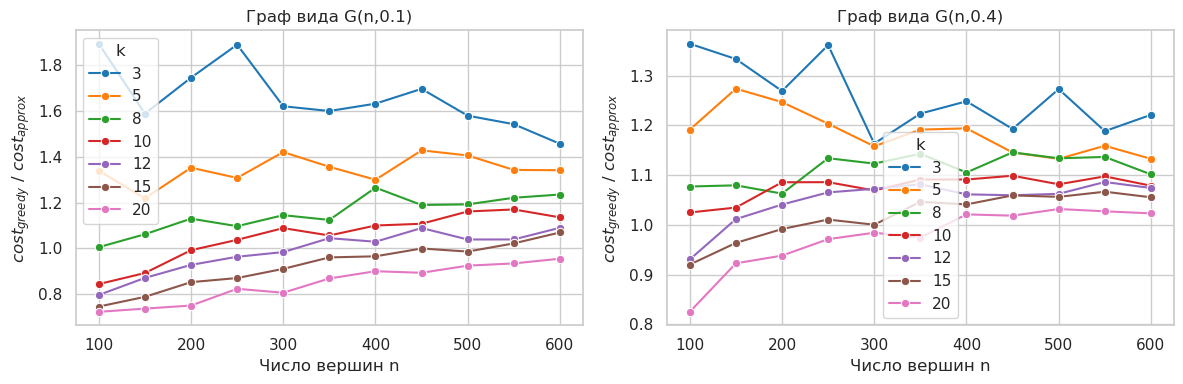

In [44]:
df = pd.read_csv("benchmark_greedy_results.csv")

df['ratio'] = df['greedy_cost'] / df['approx_cost']

df_rand = df[df['graph_type'].str.contains('random')].copy()

grouped_rand = df_rand.groupby(['graph_type', 'n', 'k'])['ratio'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

types = df_rand['graph_type'].unique()

for i, t in enumerate(types):
    cur = grouped_rand[grouped_rand['graph_type'] == t]

    sns.lineplot(data=cur,x='n',y='ratio',hue='k',marker='o',ax=axes[i], palette="tab10")

    axes[i].set_title('Граф вида G(n,' + t[-3:] + ')')
    axes[i].set_xlabel('Число вершин n')
    axes[i].set_ylabel('$cost_{greedy}$ / $cost_{approx}$')

plt.tight_layout()
plt.show()